<a href="https://colab.research.google.com/github/parveen180/Machine-learning-project-python/blob/main/Customer_Churn_Prediction_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [238]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV

In [239]:
dataset=pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [240]:
dataset.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [241]:
dataset.shape

(7043, 21)

In [242]:
for columns in dataset.columns:
  numerical_features=['MonthlyCharges','TotalCharges','tenure']
  if columns not in numerical_features:
    print(columns,dataset[columns].unique())
    print("-"*50)

customerID ['7590-VHVEG' '5575-GNVDE' '3668-QPYBK' ... '4801-JZAZL' '8361-LTMKD'
 '3186-AJIEK']
--------------------------------------------------
gender ['Female' 'Male']
--------------------------------------------------
SeniorCitizen [0 1]
--------------------------------------------------
Partner ['Yes' 'No']
--------------------------------------------------
Dependents ['No' 'Yes']
--------------------------------------------------
PhoneService ['No' 'Yes']
--------------------------------------------------
MultipleLines ['No phone service' 'No' 'Yes']
--------------------------------------------------
InternetService ['DSL' 'Fiber optic' 'No']
--------------------------------------------------
OnlineSecurity ['No' 'Yes' 'No internet service']
--------------------------------------------------
OnlineBackup ['Yes' 'No' 'No internet service']
--------------------------------------------------
DeviceProtection ['No' 'Yes' 'No internet service']
---------------------------------------

In [243]:
dataset.drop(columns='customerID',axis=1,inplace=True)

In [244]:
dataset.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No


In [245]:
dataset['TotalCharges'].value_counts()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


In [246]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [247]:
#dataset['TotalCharges']=dataset['TotalCharges'].astype(float)

In [248]:
dataset[dataset['TotalCharges']==' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [249]:
len(dataset[dataset['TotalCharges']==' '])

11

In [250]:
dataset["TotalCharges"]=dataset["TotalCharges"].replace({" ":"0.0"})

In [251]:
dataset['TotalCharges']=dataset['TotalCharges'].astype(float)

In [252]:
len(dataset[dataset['TotalCharges']==' '])

0

**Numerical data**

tenure

monthly charges

total charges

In [253]:
sns.set_theme(style='darkgrid')

Mean of tenure 32.37114865824223
Median of tenure 29.0


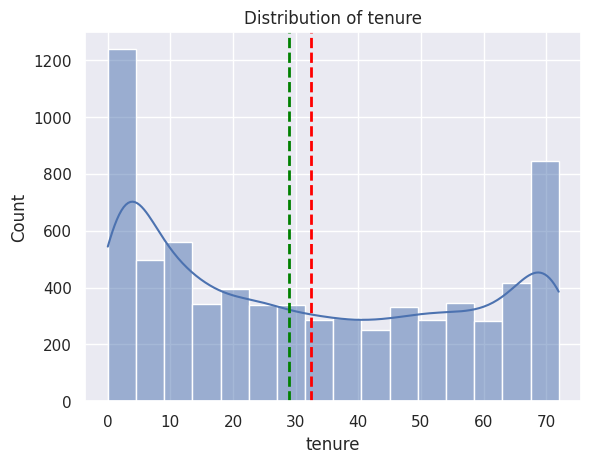

In [254]:
sns.histplot(dataset['tenure'],kde=True)
plt.title('Distribution of tenure')
tenure_mean=dataset['tenure'].mean()
tenure_median=dataset['tenure'].median()
plt.axvline(tenure_mean,color='red',linestyle='--',linewidth=2)
plt.axvline(tenure_median,color='green',linestyle='--',linewidth=2)
print('Mean of tenure',tenure_mean)
print('Median of tenure',tenure_median)
plt.show()

Mean of MonthlyCharges 64.76169246059918
Median of MonthlyCharges 70.35


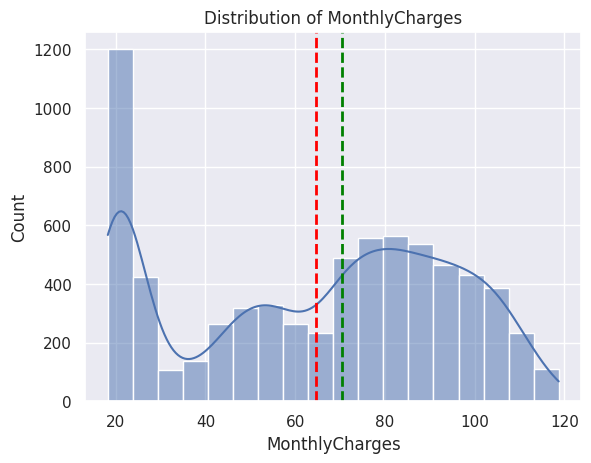

In [255]:
sns.histplot(dataset['MonthlyCharges'],kde=True)
plt.title('Distribution of MonthlyCharges')
MonthlyCharges_mean=dataset['MonthlyCharges'].mean()
MonthlyCharges_median=dataset['MonthlyCharges'].median()
plt.axvline(MonthlyCharges_mean,color='red',linestyle='--',linewidth=2)
plt.axvline(MonthlyCharges_median,color='green',linestyle='--',linewidth=2)
print('Mean of MonthlyCharges',MonthlyCharges_mean)
print('Median of MonthlyCharges',MonthlyCharges_median)
plt.show()

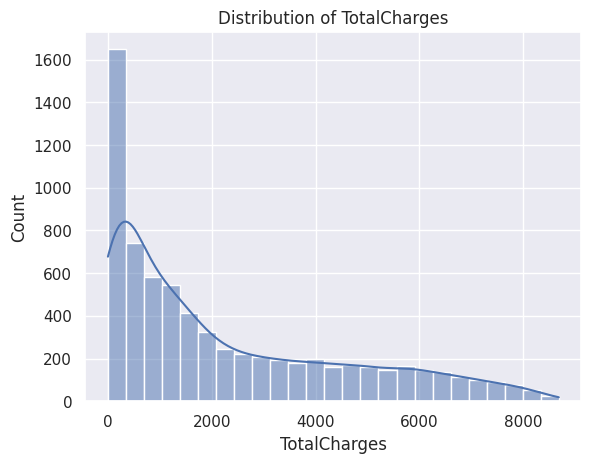

In [256]:
sns.histplot(dataset['TotalCharges'],kde=True)
plt.title('Distribution of TotalCharges')
#TotalCharges_mean=dataset['TotalCharges'].mean()
#TotalCharges_median=dataset['TotalCharges'].median()
#plt.axvline(TotalCharges_mean,color='red',linestyle='--',linewidth=2)
#plt.axvline(TotalCharges_median,color='green',linestyle='--',linewidth=2)
#print('Mean of TotalCharges',TotalCharges_mean)
#print('Median of TotalCharges',TotalCharges_median)
plt.show()

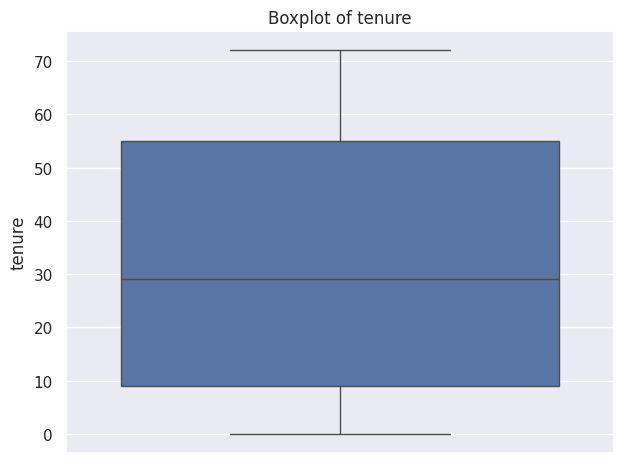

In [257]:
sns.boxplot(dataset['tenure'])
plt.title('Boxplot of tenure')
plt.tight_layout()
plt.show()

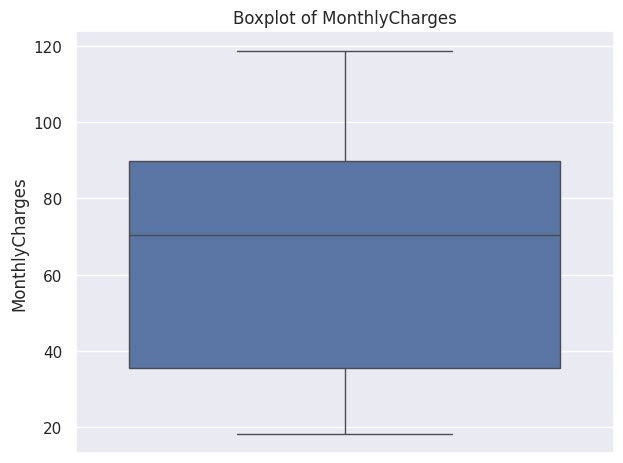

In [258]:
sns.boxplot(dataset['MonthlyCharges'])
plt.title('Boxplot of MonthlyCharges')
plt.tight_layout()
plt.show()

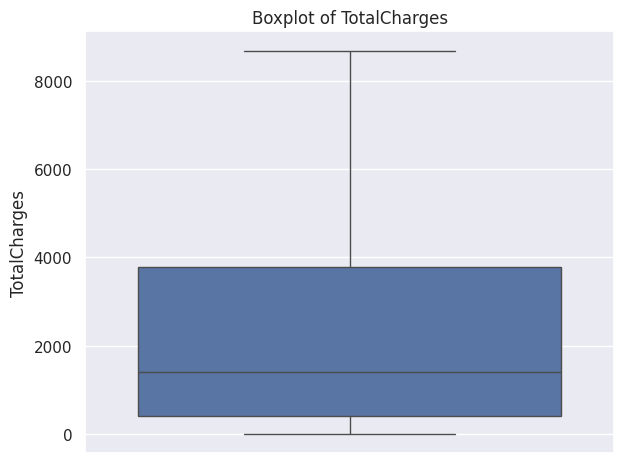

In [259]:
sns.boxplot(dataset['TotalCharges'])
plt.title('Boxplot of TotalCharges')
plt.tight_layout()
plt.show()

In [260]:
q1=dataset['tenure'].quantile(0.25)
q3=dataset['tenure'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-(1.5*iqr)
upper_bound=q3+(1.5*iqr)
tenure_outliers=dataset[(dataset['tenure']<lower_bound) | (dataset['tenure']>upper_bound)]
print(f"Number of outliers in age: {len(tenure_outliers)}")

Number of outliers in age: 0


In [261]:
dataset.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [262]:
categorical_column=(['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod'])

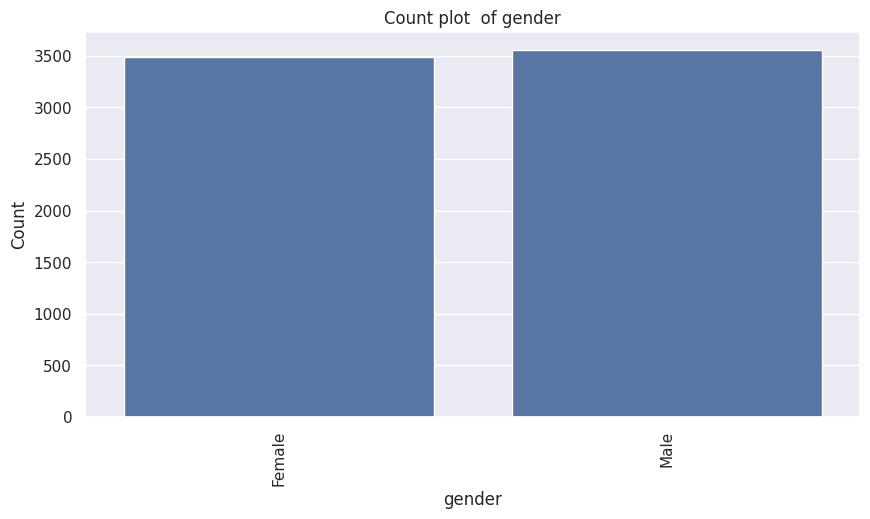

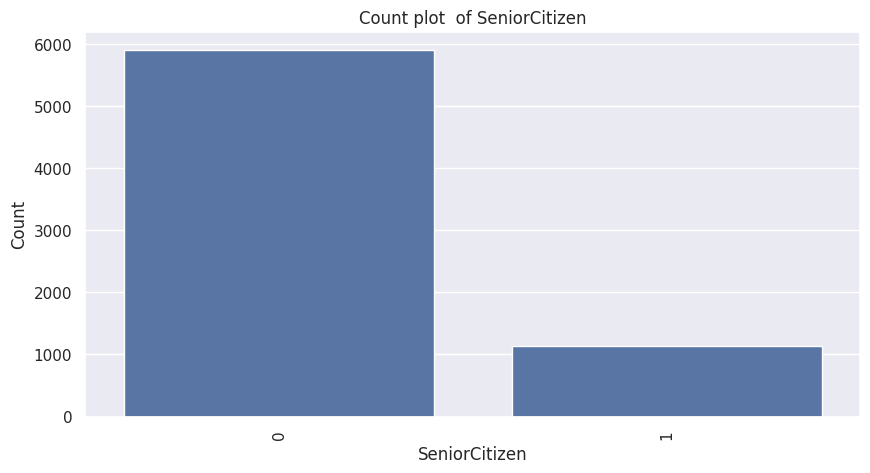

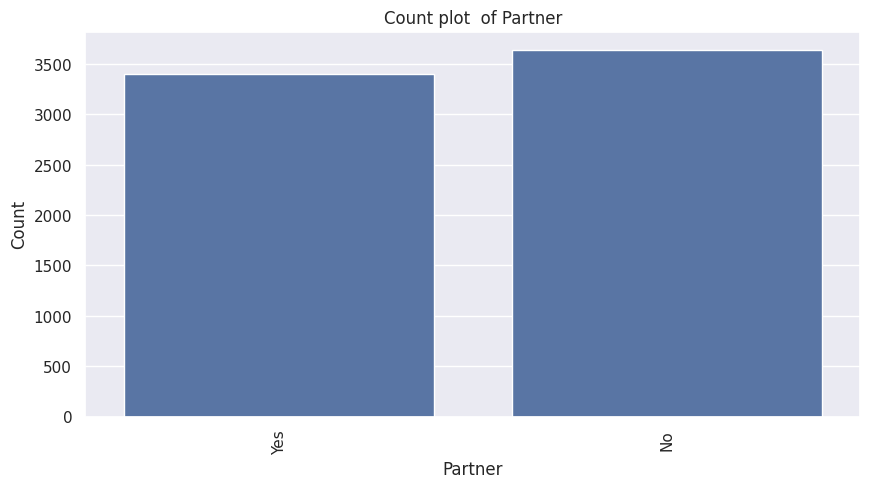

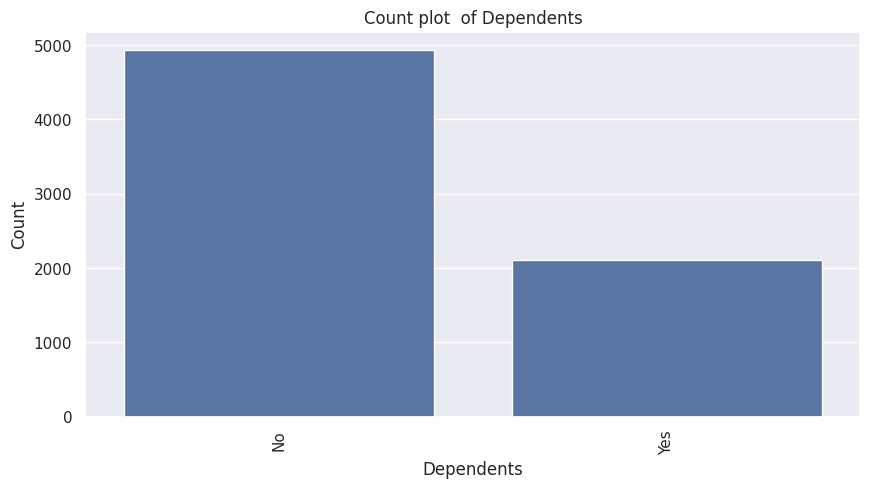

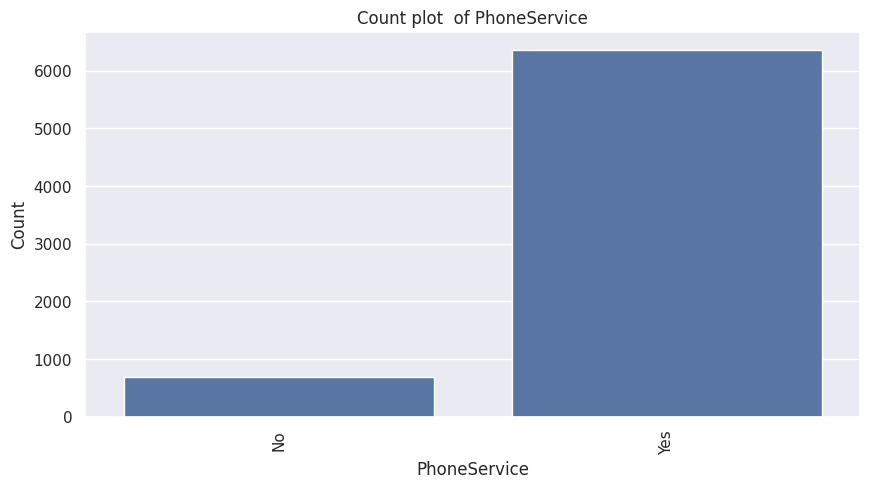

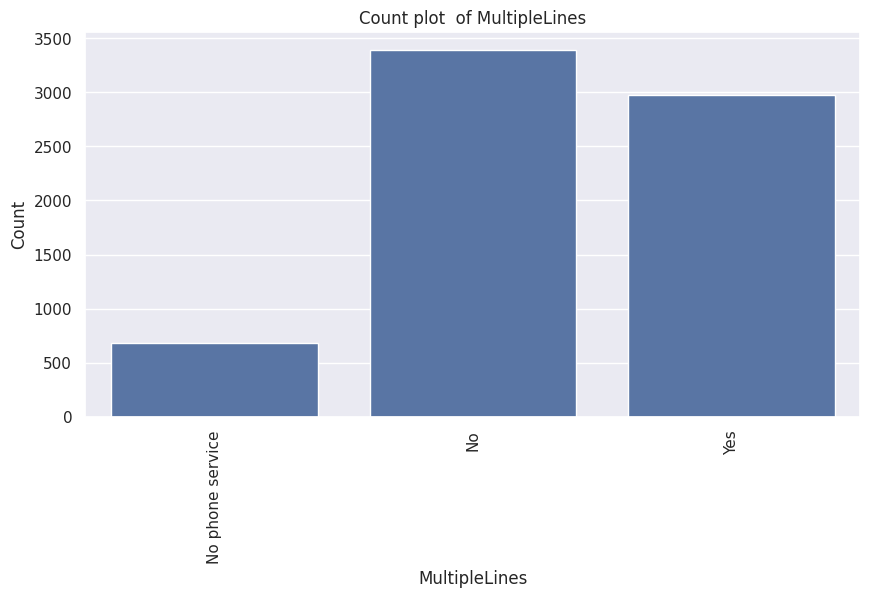

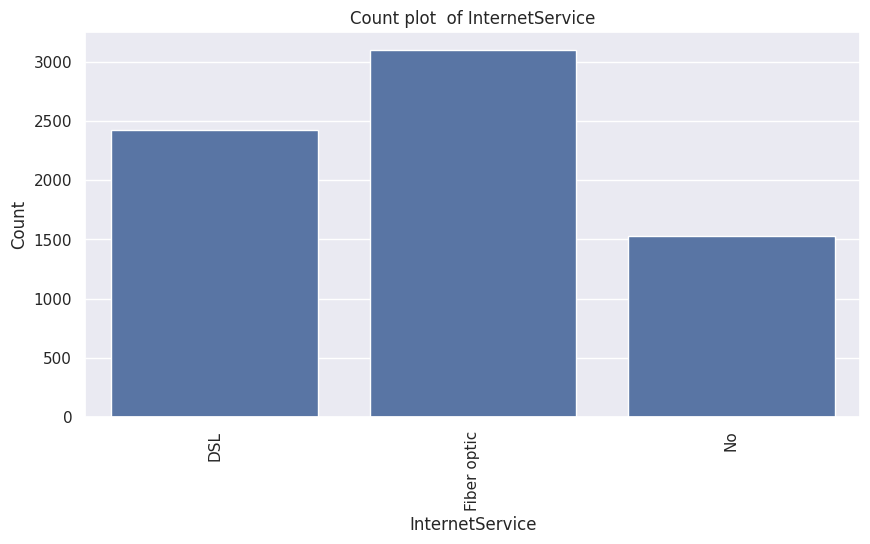

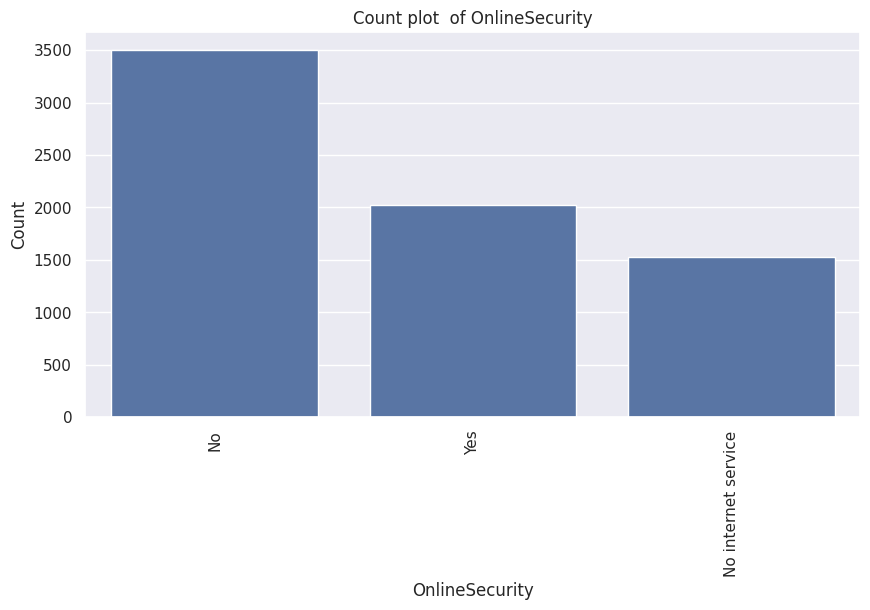

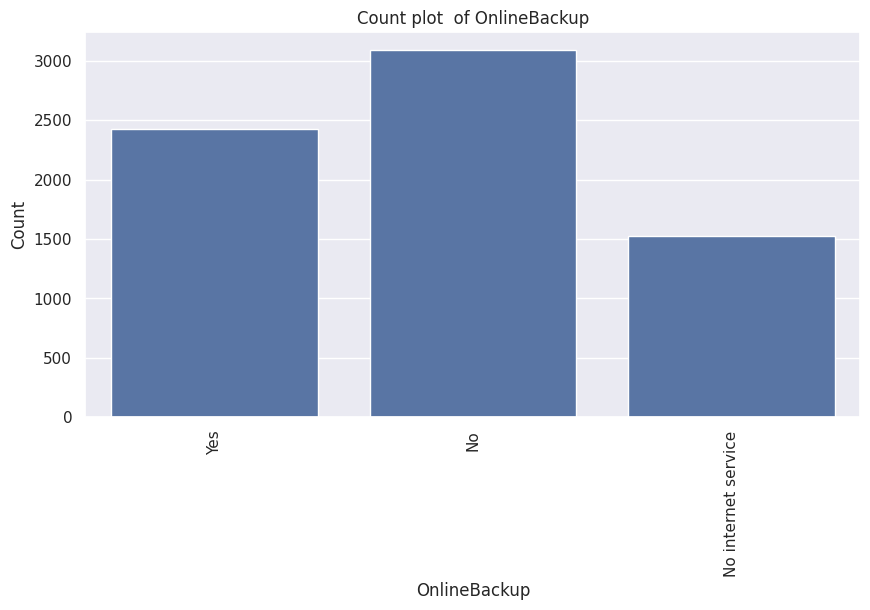

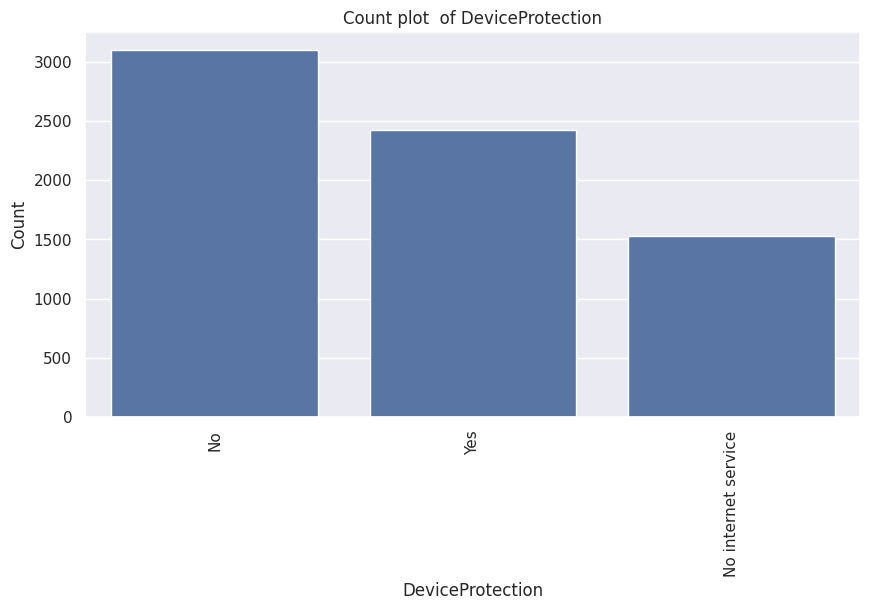

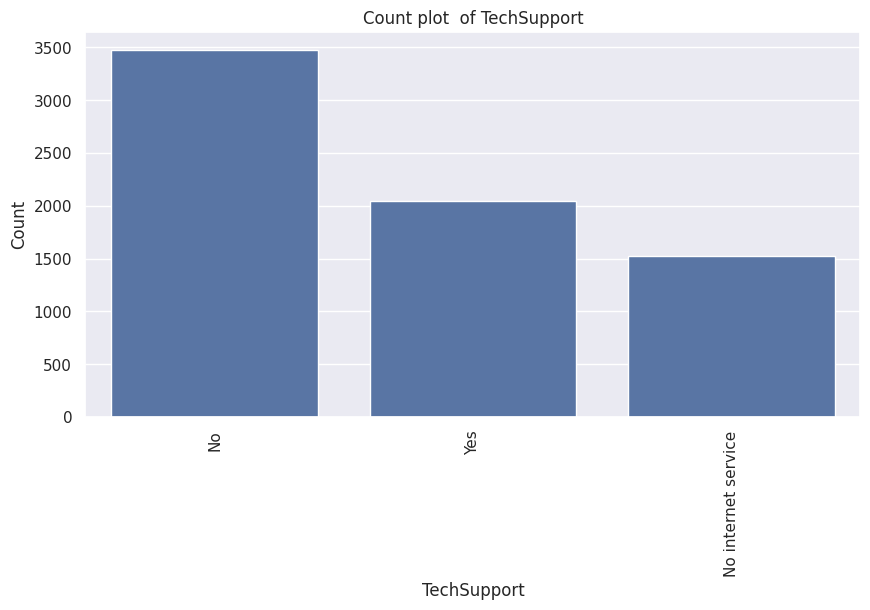

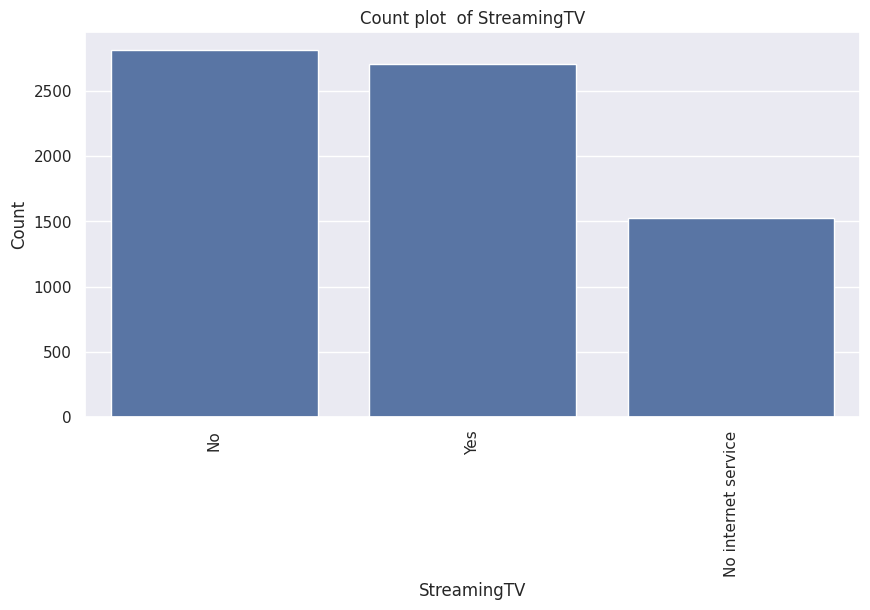

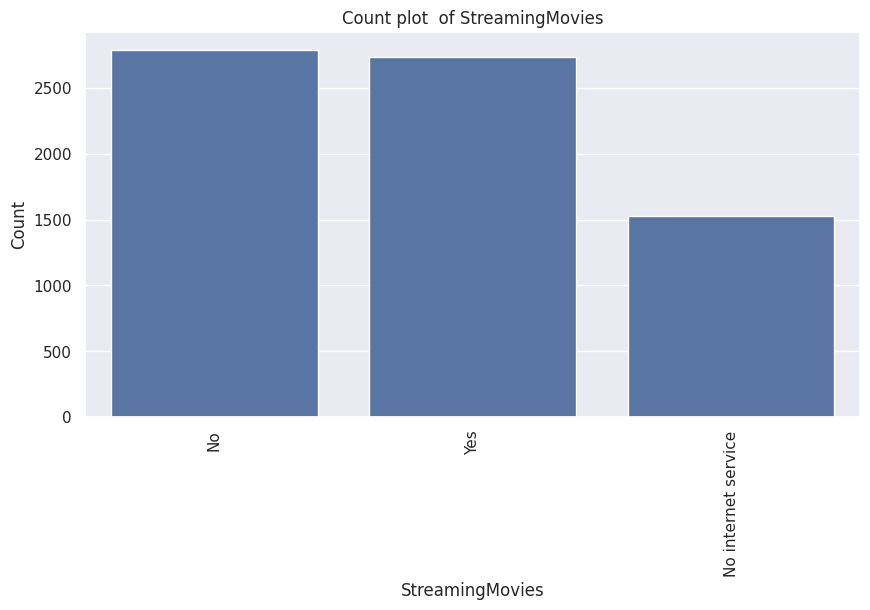

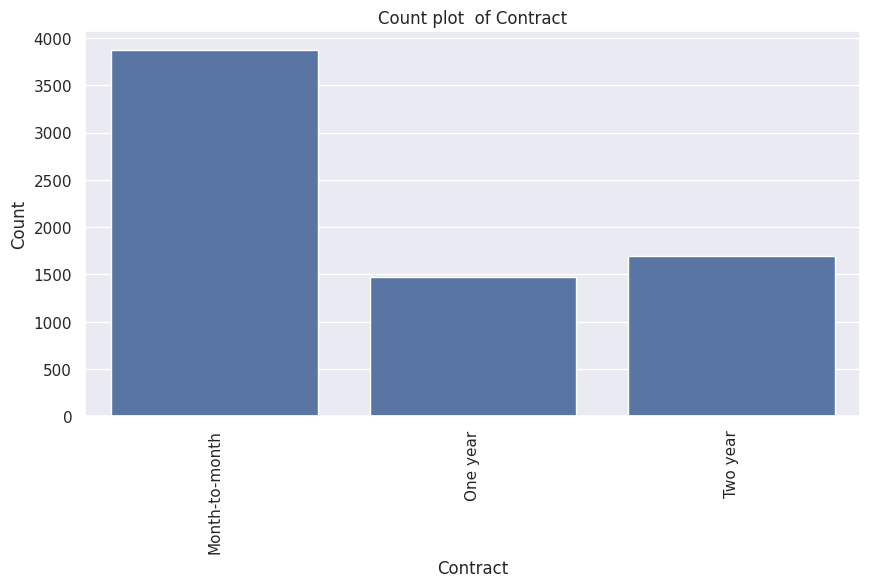

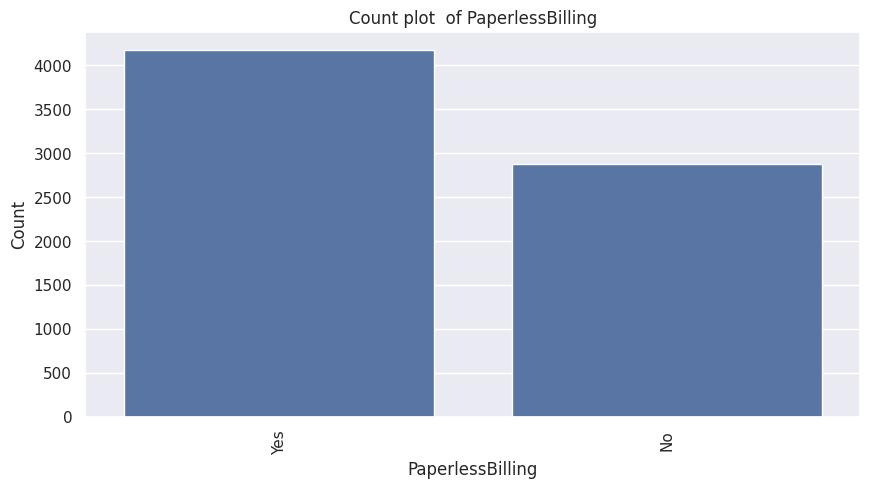

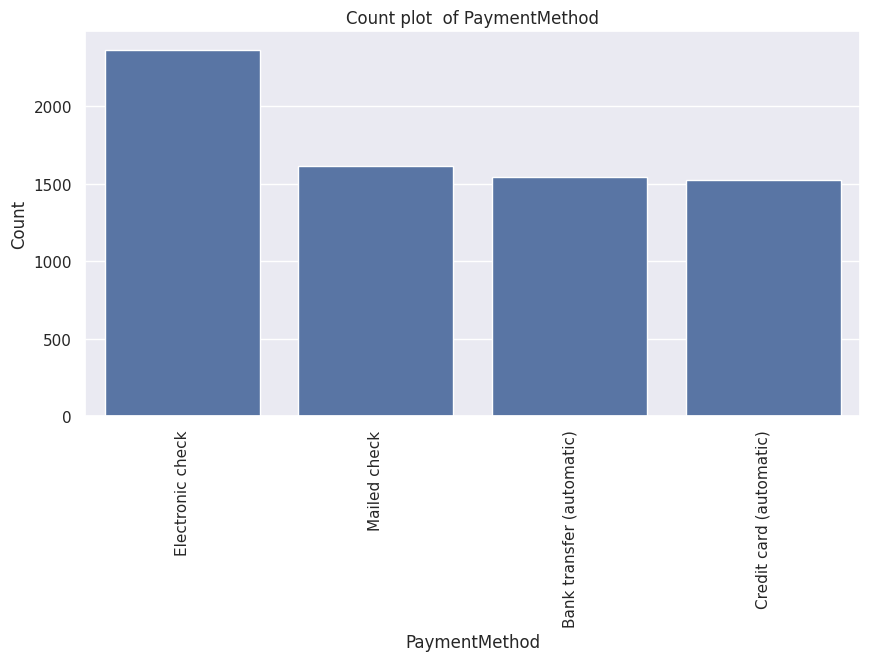

In [263]:
for column in categorical_column:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=dataset[column])
    plt.title(f"Count plot  of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.show()

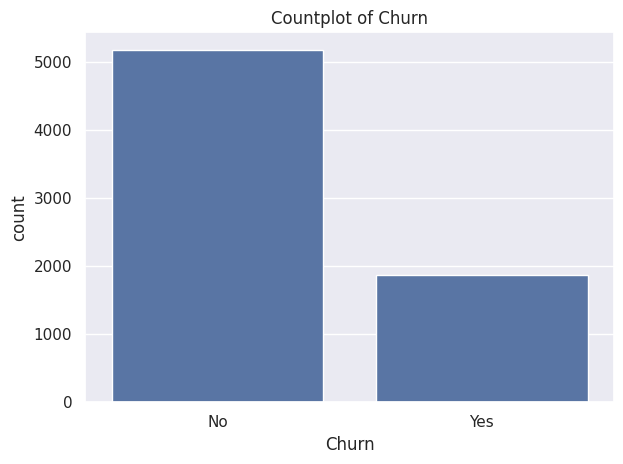

In [264]:
sns.countplot(x=dataset['Churn'])
plt.title('Countplot of Churn')
plt.tight_layout()
plt.show()

In [265]:
dataset["Churn"] = dataset["Churn"].replace({"Yes": 1, "No": 0})

/tmp/ipython-input-2622239742.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset["Churn"] = dataset["Churn"].replace({"Yes": 1, "No": 0})


In [266]:
from sklearn.preprocessing import LabelEncoder
object_column=dataset.select_dtypes(include='object').columns

In [267]:
print(object_column)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [268]:
import pickle
encoders={}
for column in object_column:
  le=LabelEncoder()
  dataset[column]=le.fit_transform(dataset[column])
  encoders[column]=le


# save the encoders as a pickle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)

In [269]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

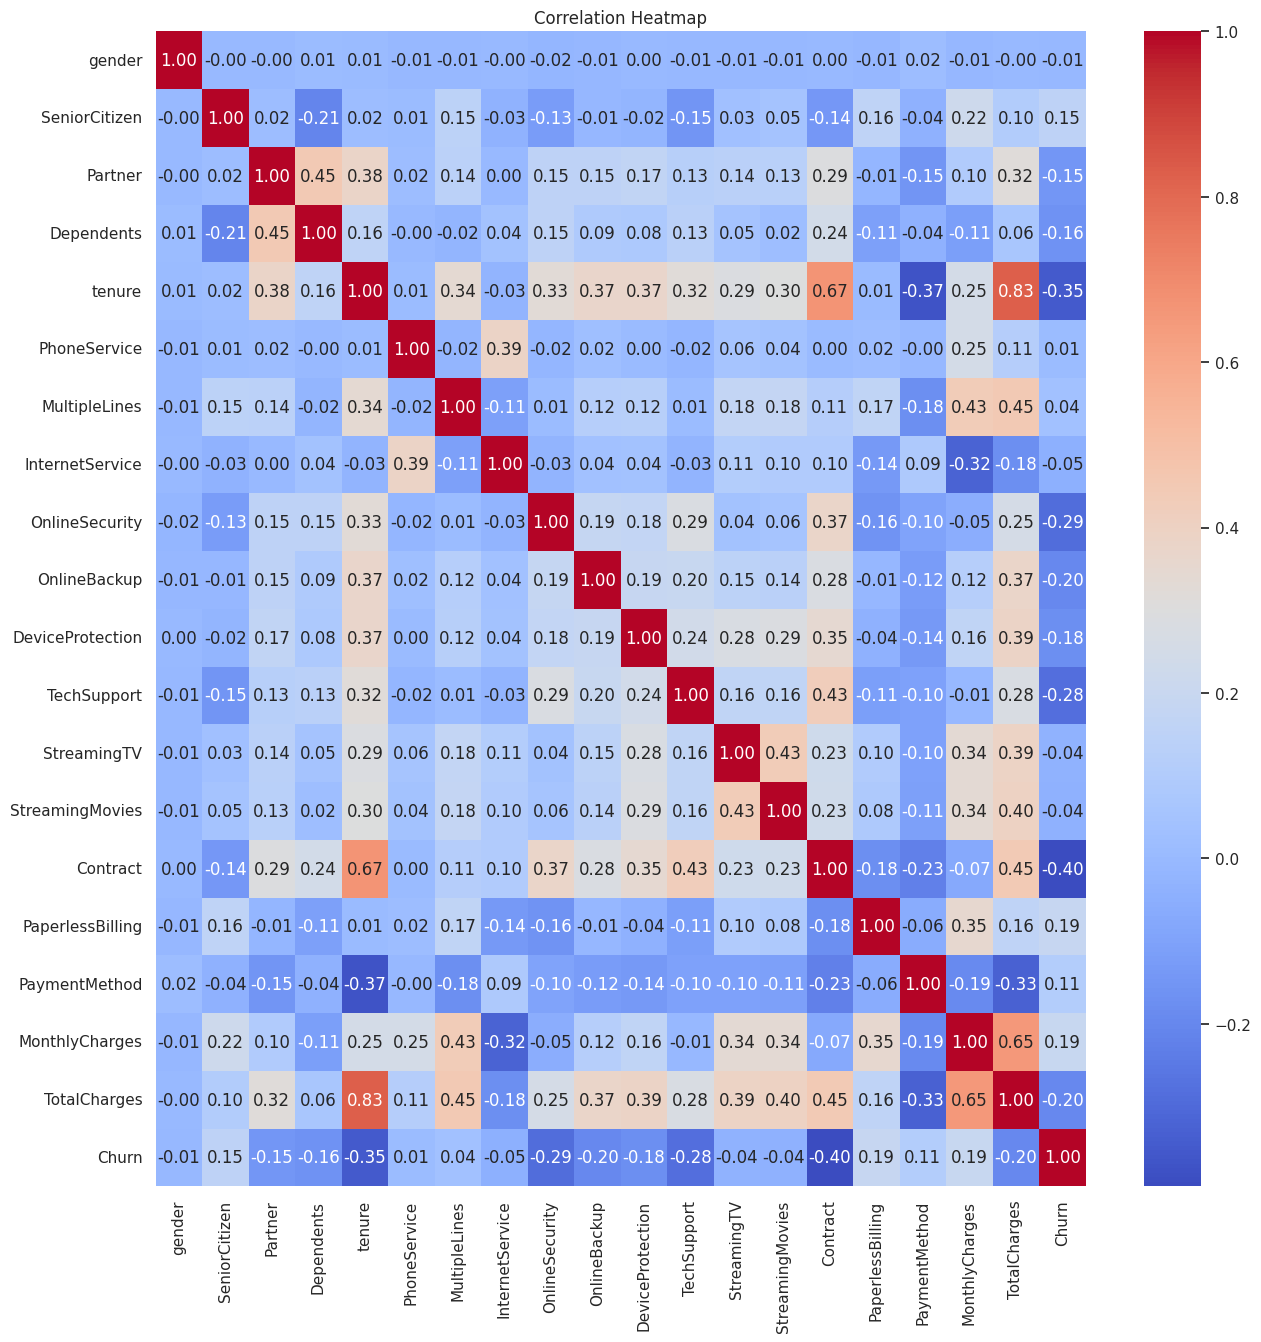

In [270]:
plt.figure(figsize=(15, 15))
sns.heatmap(dataset.corr(), annot=True, cmap='coolwarm',fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [271]:
x=dataset.drop(columns='Churn')
y=dataset['Churn']

In [272]:
print(y)

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64


In [273]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [274]:
x_train.shape

(5634, 19)

In [275]:
y_train.shape

(5634,)

In [276]:
y_train.value_counts()

,count
Churn,
0,4138
1,1496


In [277]:
y_test.value_counts()

,count
Churn,
0,1036
1,373


In [278]:
from imblearn.over_sampling import SMOTE

In [279]:
smote=SMOTE()
x_train,y_train=smote.fit_resample(x_train,y_train)

In [280]:
x_test,y_test=smote.fit_resample(x_test,y_test)

In [281]:
y_train.value_counts()

,count
Churn,
0,4138
1,4138


In [282]:
y_test.value_counts()

,count
Churn,
1,1036
0,1036


In [283]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [284]:
models={
    "Decision Tree":DecisionTreeClassifier(),
    "Random Forest":RandomForestClassifier(),
    "XGBoost":XGBClassifier()

}

In [285]:
cv_scores={}

for model_name,model in models.items():
    print(f"Training {model_name} with default parameters...")
    scores=cross_val_score(model,x_train,y_train,cv=5)
    cv_scores[model_name]=scores
    print(f"Cross validation accuracy: {np.mean(scores):.2f}")
    print("-"*50)


Training Decision Tree with default parameters...
Cross validation accuracy: 0.78
--------------------------------------------------
Training Random Forest with default parameters...
Cross validation accuracy: 0.84
--------------------------------------------------
Training XGBoost with default parameters...
Cross validation accuracy: 0.83
--------------------------------------------------


In [286]:
rfc=RandomForestClassifier()
rfc.fit(x_train,y_train)



RandomForestClassifier()

In [287]:
rfc.fit(x_train,y_train)

RandomForestClassifier()

In [288]:
# evaluate on test data
y_test_pred = rfc.predict(x_test)

print("Accuracy Score:\n", accuracy_score(y_test, y_test_pred))
print("Confsuion Matrix:\n", confusion_matrix(y_test, y_test_pred))
print("Classification Report:\n", classification_report(y_test, y_test_pred))

Accuracy Score:
 0.819015444015444
Confsuion Matrix:
 [[871 165]
 [210 826]]
Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.84      0.82      1036
           1       0.83      0.80      0.81      1036

    accuracy                           0.82      2072
   macro avg       0.82      0.82      0.82      2072
weighted avg       0.82      0.82      0.82      2072



In [289]:
# save the trained model as a pickle file
model_data = {"model": rfc, "features_names": x.columns.tolist()}


with open("customer_churn_model.pkl", "wb") as f:
  pickle.dump(model_data, f)

In [290]:
# load the saved model and the feature names

with open("customer_churn_model.pkl", "rb") as f:
  model_data = pickle.load(f)

loaded_model = model_data["model"]
feature_names = model_data["features_names"]

In [291]:
print(loaded_model)

RandomForestClassifier()


In [292]:
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [295]:
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}


input_data_df = pd.DataFrame([input_data])

with open("encoders.pkl", "rb") as f:
  encoders = pickle.load(f)


# encode categorical featires using teh saved encoders
for column, encoder in encoders.items():
  input_data_df[column] = encoder.transform(input_data_df[column])

# make a prediction
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print(prediction)
print(pred_prob)

if prediction == 1:
    print("Customer will churn")
else:
    print("Customer will not churn")

[0]
[[0.78 0.22]]
Customer will not churn
